In [1]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_squared_error

print("numpy:", np.__version__)
print("torch:", torch.__version__)

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

numpy: 1.26.4
torch: 2.2.1+cu121
device: cuda


In [2]:
bat_df = pd.read_pickle("data/bat_df.pkl")
print(bat_df.shape)

(124, 12)


In [3]:
# Splits from original paper
numBat1 = 41
numBat2 = 43
numBat3 = 40
numBat = numBat1 + numBat2 + numBat3

test_ind = np.hstack((np.arange(0, (numBat1 + numBat2), 2), 83))
train_ind = np.arange(1, (numBat1 + numBat2 - 1), 2)
secondary_test_ind = np.arange(numBat - numBat3, numBat)

train_df = bat_df.iloc[train_ind].reset_index(drop=True)
primary_test_df = bat_df.iloc[test_ind].reset_index(drop=True)
secondary_test_df = bat_df.iloc[secondary_test_ind].reset_index(drop=True)

print("train_df:", train_df.shape)
print("primary_test_df:", primary_test_df.shape)
print("secondary_test_df:", secondary_test_df.shape)

train_df: (41, 12)
primary_test_df: (43, 12)
secondary_test_df: (40, 12)


In [4]:
# Directly fix outlier QD: b1c18, cycle 40
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c18"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[39] = 0.5 * (QD[38] + QD[40])   # cycle_idx 39 = cycle 40
primary_test_df.at[idx, "QD"] = QD

# Directly fix outlier QD: b1c0, cycle 12
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c0"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[11] = 0.5 * (QD[10] + QD[12])   # cycle_idx 11 = cycle 12
primary_test_df.at[idx, "QD"] = QD

In [5]:
# BUILD FNO DATASET FROM RAW Qdlin CURVES
# Input per battery: ΔQdlin_k(V) = Qdlin_k(V) - Qdlin_10(V), cycles 10–100
# Output per battery: log10(cycle_life)

START_IDX = 9      # cycle 10
END_IDX = 99       # cycle 100
REF_IDX = 9        # cycle 10
N_VOLTAGE = 1000

def get_qdlin_1000(cyc):
    q = np.asarray(cyc["Qdlin"], dtype=float).squeeze()

    if q.shape[0] != N_VOLTAGE:
        return None

    return q

def build_fno_arrays(df, split_name):
    X_list = []
    y_list = []
    battery_ids = []

    for _, row in df.iterrows():
        cycles_dict = row["cycles"]

        if str(REF_IDX) not in cycles_dict:
            print(f"Skipping {row['battery_id']} in {split_name}: missing reference cycle")
            continue

        q_ref = get_qdlin_1000(cycles_dict[str(REF_IDX)])

        if q_ref is None:
            print(f"Skipping {row['battery_id']} in {split_name}: bad reference Qdlin shape")
            continue

        battery_tensor = []
        valid = True

        for cyc_idx in range(START_IDX, END_IDX + 1):
            if str(cyc_idx) not in cycles_dict:
                valid = False
                break

            q = get_qdlin_1000(cycles_dict[str(cyc_idx)])

            if q is None:
                valid = False
                break

            dq = q - q_ref
            battery_tensor.append(dq)

        if not valid:
            print(f"Skipping {row['battery_id']} in {split_name}: missing/bad Qdlin")
            continue

        # Shape: [91 cycles, 1000 voltage points, 1 channel]
        battery_tensor = np.stack(battery_tensor, axis=0)[..., None]

        X_list.append(battery_tensor)
        y_list.append(np.log10(row["cycle_life"]))
        battery_ids.append(row["battery_id"])

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32).reshape(-1, 1)

    print(split_name)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, battery_ids

X_train, y_train, train_ids = build_fno_arrays(train_df, "train")
X_primary, y_primary, primary_ids = build_fno_arrays(primary_test_df, "primary_test")
X_secondary, y_secondary, secondary_ids = build_fno_arrays(secondary_test_df, "secondary_test")

train
X shape: (41, 91, 1000, 1)
y shape: (41, 1)
primary_test
X shape: (43, 91, 1000, 1)
y shape: (43, 1)
secondary_test
X shape: (40, 91, 1000, 1)
y shape: (40, 1)


In [6]:
# Normalize FNO inputs using train set only
X_mean = X_train.mean()
X_std = X_train.std() + 1e-8

X_train_n = (X_train - X_mean) / X_std
X_primary_n = (X_primary - X_mean) / X_std
X_secondary_n = (X_secondary - X_mean) / X_std

# Normalize log10(cycle_life) target using train set only
y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_n = (y_train - y_mean) / y_std
y_primary_n = (y_primary - y_mean) / y_std
y_secondary_n = (y_secondary - y_mean) / y_std

X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
y_train_t = torch.tensor(y_train_n, dtype=torch.float32)

X_primary_t = torch.tensor(X_primary_n, dtype=torch.float32)
y_primary_t = torch.tensor(y_primary_n, dtype=torch.float32)

X_secondary_t = torch.tensor(X_secondary_n, dtype=torch.float32)
y_secondary_t = torch.tensor(y_secondary_n, dtype=torch.float32)

print("X_train_t:", X_train_t.shape)
print("y_train_t:", y_train_t.shape)

X_train_t: torch.Size([41, 91, 1000, 1])
y_train_t: torch.Size([41, 1])


In [7]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_cycle, modes_voltage):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_cycle = modes_cycle
        self.modes_voltage = modes_voltage

        scale = 1 / (in_channels * out_channels)

        self.weights = nn.Parameter(
            scale * torch.randn(
                in_channels,
                out_channels,
                modes_cycle,
                modes_voltage,
                dtype=torch.cfloat
            )
        )

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]

        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :self.modes_cycle, :self.modes_voltage] = self.compl_mul2d(
            x_ft[:, :, :self.modes_cycle, :self.modes_voltage],
            self.weights
        )

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x


class FNO2dBattery(nn.Module):
    def __init__(self, in_channels=1, width=16, modes_cycle=10, modes_voltage=24, dropout=0.10):
        super().__init__()

        self.width = width

        # +2 coordinate channels: cycle coordinate and voltage coordinate
        self.fc0 = nn.Linear(in_channels + 2, width)

        self.conv0 = SpectralConv2d(width, width, modes_cycle, modes_voltage)
        self.conv1 = SpectralConv2d(width, width, modes_cycle, modes_voltage)
        self.conv2 = SpectralConv2d(width, width, modes_cycle, modes_voltage)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)

        self.regressor = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def get_grid(self, batchsize, size_cycle, size_voltage, device):
        cycle_grid = torch.linspace(0, 1, size_cycle, device=device)
        voltage_grid = torch.linspace(0, 1, size_voltage, device=device)

        cycle_grid = cycle_grid.reshape(1, size_cycle, 1, 1).repeat(batchsize, 1, size_voltage, 1)
        voltage_grid = voltage_grid.reshape(1, 1, size_voltage, 1).repeat(batchsize, size_cycle, 1, 1)

        return torch.cat([cycle_grid, voltage_grid], dim=-1)

    def forward(self, x):
        # x shape: [batch, cycles, voltage, channels]
        batchsize, size_cycle, size_voltage, channels = x.shape

        grid = self.get_grid(batchsize, size_cycle, size_voltage, x.device)
        x = torch.cat([x, grid], dim=-1)

        x = self.fc0(x)

        # [batch, cycles, voltage, width] -> [batch, width, cycles, voltage]
        x = x.permute(0, 3, 1, 2)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))

        # Global average pooling over cycle and voltage dimensions
        x = x.mean(dim=(-2, -1))

        out = self.regressor(x)

        return out

In [8]:
# FNO model training function

def train_fno_model(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=300,
    tol=1e-5,
    suppress_print=False
):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = np.inf
    best_state = None

    train_losses = []
    val_losses = []

    model.to(device)

    for epoch in range(epochs):

        # Training
        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)

            # Same as MLP notebook: RMSE loss on normalized target
            loss = torch.sqrt(criterion(preds, y_batch))

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # Validation
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)

                loss = torch.sqrt(criterion(preds, y_batch))

                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # This keeps the actual best validation model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        if not suppress_print and epoch % 100 == 0:
            print(
                f"Epoch {epoch:3d} | "
                f"Train Loss: {avg_train_loss:.6f} | "
                f"Val Loss: {avg_val_loss:.6f}"
            )

    model.load_state_dict(best_state)

    return model, train_losses, val_losses


# FNO K-fold Cross-validation

from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader

def cross_validate_fno_model(
    config,
    X_array,
    y_array,
    n_splits=4
):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_losses = []

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_array)
    ):

        print(f"\nFold {fold+1}/{n_splits}")

        # Split
        X_train_fold = X_array[train_idx]
        X_val_fold = X_array[val_idx]

        y_train_fold = y_array[train_idx]
        y_val_fold = y_array[val_idx]

        # Scale FNO inputs using training fold only
        X_mean_fold = X_train_fold.mean()
        X_std_fold = X_train_fold.std() + 1e-8

        X_train_scaled = (X_train_fold - X_mean_fold) / X_std_fold
        X_val_scaled = (X_val_fold - X_mean_fold) / X_std_fold

        # Scale target using training fold only
        y_mean_fold = y_train_fold.mean()
        y_std_fold = y_train_fold.std() + 1e-8

        y_train_scaled = (y_train_fold - y_mean_fold) / y_std_fold
        y_val_scaled = (y_val_fold - y_mean_fold) / y_std_fold

        # Tensors
        X_train_tensor = torch.tensor(
            X_train_scaled,
            dtype=torch.float32
        )

        y_train_tensor = torch.tensor(
            y_train_scaled,
            dtype=torch.float32
        )

        X_val_tensor = torch.tensor(
            X_val_scaled,
            dtype=torch.float32
        )

        y_val_tensor = torch.tensor(
            y_val_scaled,
            dtype=torch.float32
        )

        # Dataloaders
        train_dataset = TensorDataset(
            X_train_tensor,
            y_train_tensor
        )

        val_dataset = TensorDataset(
            X_val_tensor,
            y_val_tensor
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=config["batch_size"],
            shuffle=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config["batch_size"],
            shuffle=False
        )

        # FNO model
        model = FNO2dBattery(
            in_channels=1,
            width=config["width"],
            modes_cycle=config["modes_cycle"],
            modes_voltage=config["modes_voltage"],
            dropout=config["dropout"]
        )

        # Train
        model, _, val_losses = train_fno_model(
            model,
            train_loader,
            val_loader,
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            epochs=config["epochs"],
            tol=config["tol"]
        )

        best_fold_loss = min(val_losses)

        print(
            f"Best Fold Validation Loss: "
            f"{best_fold_loss:.6f}"
        )

        fold_losses.append(best_fold_loss)

    mean_cv_loss = np.mean(fold_losses)

    print("\nMean CV Loss:", mean_cv_loss)

    return mean_cv_loss

In [9]:
# FNO hyperparameter search

fno_configs = [
    # {
    #     "width": 8,
    #     "modes_cycle": 6,
    #     "modes_voltage": 12,
    #     "dropout": 0.10,
    #     "lr": 1e-3,
    #     "weight_decay": 1e-4,
    #     "epochs": 300,
    #     "tol": 1e-5,
    #     "batch_size": 8,
    # },
    # {
    #     "width": 12,
    #     "modes_cycle": 8,
    #     "modes_voltage": 16,
    #     "dropout": 0.10,
    #     "lr": 1e-3,
    #     "weight_decay": 1e-4,
    #     "epochs": 300,
    #     "tol": 1e-5,
    #     "batch_size": 8,
    # },
    {
        "width": 16,
        "modes_cycle": 10,
        "modes_voltage": 24,
        "dropout": 0.10,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 300,
        "tol": 1e-5,
        "batch_size": 8,
    },
]

cv_results = []

for i, config in enumerate(fno_configs):

    print("\n==============================")
    print(f"Config {i+1}/{len(fno_configs)}")
    print(config)
    print("==============================")

    mean_cv_loss = cross_validate_fno_model(
        config=config,
        X_array=X_train,
        y_array=y_train,
        n_splits=4
    )

    result = config.copy()
    result["mean_cv_loss"] = mean_cv_loss

    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("mean_cv_loss").reset_index(drop=True)

display(cv_results_df)

best_config = cv_results_df.iloc[0].to_dict()
print("Best config:")
print(best_config)


Config 1/1
{'width': 16, 'modes_cycle': 10, 'modes_voltage': 24, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 300, 'tol': 1e-05, 'batch_size': 8}

Fold 1/4
Epoch   0 | Train Loss: 0.963753 | Val Loss: 0.665324
Epoch 100 | Train Loss: 0.655881 | Val Loss: 0.593765
Epoch 200 | Train Loss: 0.423979 | Val Loss: 0.592019
Best Fold Validation Loss: 0.516510

Fold 2/4
Epoch   0 | Train Loss: 0.926890 | Val Loss: 1.106823
Epoch 100 | Train Loss: 0.866219 | Val Loss: 1.109355
Epoch 200 | Train Loss: 0.554076 | Val Loss: 0.852742
Best Fold Validation Loss: 0.695184

Fold 3/4
Epoch   0 | Train Loss: 0.950534 | Val Loss: 0.988821
Epoch 100 | Train Loss: 0.923466 | Val Loss: 0.975855
Epoch 200 | Train Loss: 0.945589 | Val Loss: 0.974021
Best Fold Validation Loss: 0.966922

Fold 4/4
Epoch   0 | Train Loss: 0.986955 | Val Loss: 0.959514
Epoch 100 | Train Loss: 0.915096 | Val Loss: 0.854080
Epoch 200 | Train Loss: 0.460353 | Val Loss: 0.486988
Best Fold Validation Loss: 0.471940

Me

,width,modes_cycle,modes_voltage,dropout,lr,weight_decay,epochs,tol,batch_size,mean_cv_loss
0,16,10,24,0.1,0.001,0.0001,300,0.00001,8,0.662639


Best config:
{'width': 16.0, 'modes_cycle': 10.0, 'modes_voltage': 24.0, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 300.0, 'tol': 1e-05, 'batch_size': 8.0, 'mean_cv_loss': 0.6626390740275383}


In [16]:
# Train final FNO model on all training data using best CV config

# -----------------------------
# Scale full train / test using full train only
# -----------------------------

X_mean = X_train.mean()
X_std = X_train.std() + 1e-8

X_train_scaled = (X_train - X_mean) / X_std
X_primary_scaled = (X_primary - X_mean) / X_std
X_secondary_scaled = (X_secondary - X_mean) / X_std

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_primary_scaled = (y_primary - y_mean) / y_std
y_secondary_scaled = (y_secondary - y_mean) / y_std

# -----------------------------
# Convert to tensors
# -----------------------------

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_primary_tensor = torch.tensor(X_primary_scaled, dtype=torch.float32)
y_primary_tensor = torch.tensor(y_primary_scaled, dtype=torch.float32)

X_secondary_tensor = torch.tensor(X_secondary_scaled, dtype=torch.float32)
y_secondary_tensor = torch.tensor(y_secondary_scaled, dtype=torch.float32)

# -----------------------------
# Dataloader
# -----------------------------

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=int(best_config["batch_size"]),
    shuffle=True
)

# -----------------------------
# Final FNO model
# -----------------------------

best_model = FNO2dBattery(
    in_channels=1,
    width=int(best_config["width"]),
    modes_cycle=int(best_config["modes_cycle"]),
    modes_voltage=int(best_config["modes_voltage"]),
    dropout=float(best_config["dropout"])
)

# Use train_loader as val_loader only to reuse the same train function.
# Final real evaluation is done in the next cell on train/primary/secondary.
best_model, train_losses, val_losses = train_fno_model(
    best_model,
    train_loader,
    train_loader,
    lr=float(best_config["lr"]),
    weight_decay=float(best_config["weight_decay"]),
    epochs=500,
    tol=float(best_config["tol"]),
    suppress_print=False
)

Epoch   0 | Train Loss: 0.918795 | Val Loss: 0.884453
Epoch 100 | Train Loss: 0.883031 | Val Loss: 1.260196
Epoch 200 | Train Loss: 0.629141 | Val Loss: 0.700368
Epoch 300 | Train Loss: 0.496215 | Val Loss: 0.489243
Epoch 400 | Train Loss: 0.417885 | Val Loss: 0.414241


,split,rmse_cycles,mean_percent_error
0,train,246.630432,11935.950470
1,primary_test,353.084442,525411.230469
2,secondary_test,220.163818,661.842060


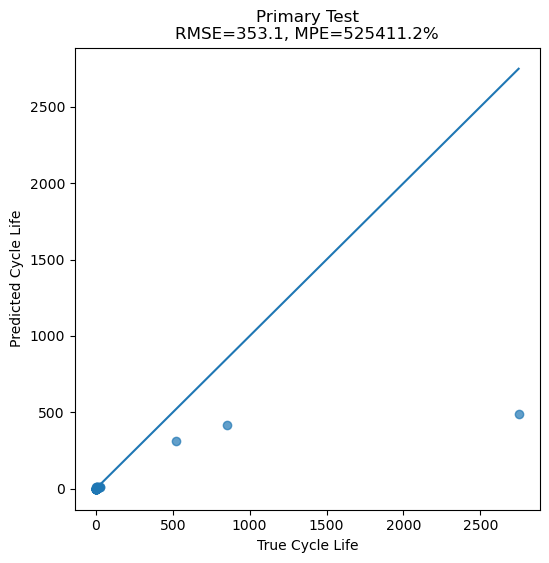

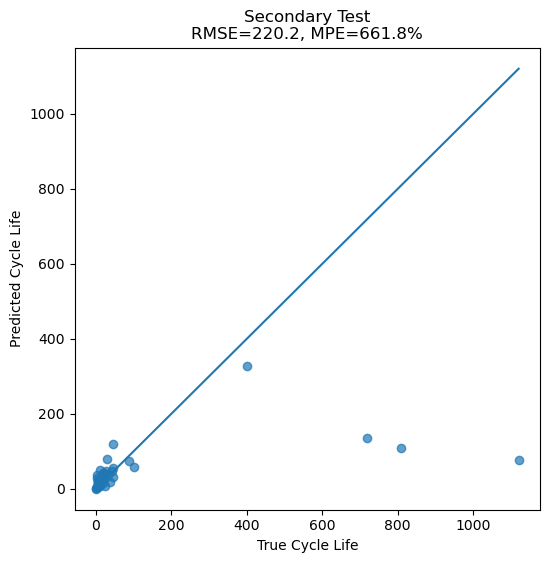

In [21]:
# Final results

best_model.eval()

# Train predictions

with torch.no_grad():

    train_pred_log = (
        best_model(X_train_tensor.to(device))
        .cpu()
        .numpy()
        .flatten()
    )

train_pred = 10 ** train_pred_log
train_true = 10 ** y_train_scaled

train_rmse = np.sqrt(
    mean_squared_error(train_true, train_pred)
)

train_mpe = np.mean(
    np.abs(train_pred - train_true) / train_true
) * 100

# Primary test predictions

with torch.no_grad():

    primary_pred_log = (
        best_model(X_primary_tensor.to(device))
        .cpu()
        .numpy()
        .flatten()
    )

primary_pred = 10 ** primary_pred_log
primary_true = 10 ** y_primary_scaled

primary_rmse = np.sqrt(
    mean_squared_error(primary_true, primary_pred)
)

primary_mpe = np.mean(
    np.abs(primary_pred - primary_true) / primary_true
) * 100

# Secondary test predictions

with torch.no_grad():

    secondary_pred_log = (
        best_model(X_secondary_tensor.to(device))
        .cpu()
        .numpy()
        .flatten()
    )

secondary_pred = 10 ** secondary_pred_log
secondary_true = 10 ** y_secondary_scaled

secondary_rmse = np.sqrt(
    mean_squared_error(
        secondary_true,
        secondary_pred
    )
)

secondary_mpe = np.mean(
    np.abs(
        secondary_pred - secondary_true
    ) / secondary_true
) * 100

# Summary table

summary_df = pd.DataFrame({

    "split": [
        "train",
        "primary_test",
        "secondary_test"
    ],

    "rmse_cycles": [
        train_rmse,
        primary_rmse,
        secondary_rmse
    ],

    "mean_percent_error": [
        train_mpe,
        primary_mpe,
        secondary_mpe
    ]
})

display(summary_df)

# Primary test plot
plt.figure(figsize=(6, 6))
plt.scatter(
    primary_true,
    primary_pred,
    alpha=0.7
)

lims = [
    min(primary_true.min(), primary_pred.min()),
    max(primary_true.max(), primary_pred.max())
]

plt.plot(lims, lims)
plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(
    f"Primary Test\n"
    f"RMSE={primary_rmse:.1f}, "
    f"MPE={primary_mpe:.1f}%"
)
plt.show()

# Secondary test plot
plt.figure(figsize=(6, 6))

plt.scatter(
    secondary_true,
    secondary_pred,
    alpha=0.7
)

lims = [
    min(
        secondary_true.min(),
        secondary_pred.min()
    ),
    max(
        secondary_true.max(),
        secondary_pred.max()
    )
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")

plt.title(
    f"Secondary Test\n"
    f"RMSE={secondary_rmse:.1f}, "
    f"MPE={secondary_mpe:.1f}%"
)

plt.show()